# Assignment 05 — Bài Toán 2: Nhận Diện Hoa (Flowers Recognition) với CNN & Transfer Learning
**Môn học:** Phát triển các Hệ thống Thông minh (ISD)  
**Quy trình khép kín (End-to-End Pipeline):**
1. **EDA & Khám phá Dữ liệu Hoa:** 4,317 ảnh tự nhiên thuộc 5 lớp: *Daisy, Dandelion, Rose, Sunflower, Tulip*.
2. **Data Augmentation:** Tăng cường dữ liệu chống overfitting trên tập ảnh nhỏ (Flip, Rotation, Zoom, Contrast).
3. **Hiện thực & Huấn luyện Mô hình:**
   - **Basic CNN (From Scratch):** Huấn luyện từ đầu làm mốc đối chuẩn.
   - **VGG-16 (Transfer Learning):** Sử dụng đặc trưng trích xuất từ ImageNet, đóng băng backbone (Frozen base).
   - **ResNet-50 (Transfer Learning):** Tận dụng Residual backbone pretrained.
4. **Đánh giá & So sánh đối chuẩn:** Phân tích sự vượt trội của Transfer Learning (>91% so với ~68%).
5. **Explainable AI (XAI):** Trực quan hóa vùng đặc trưng nhận dạng hoa bằng **Grad-CAM**.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from PIL import Image

project_root = Path("..").resolve()
sys.path.append(str(project_root))

from src.data_loader import load_flowers, find_flowers_dir
from src.models import build_basic_cnn, build_vgg16_transfer, build_resnet50_transfer
from src.train import compile_and_train
from src.evaluate import evaluate_multiclass, count_parameters
from src.visualize import plot_training_history, plot_confusion_matrix, plot_model_comparison_bar

tf.keras.utils.set_random_seed(42)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


---
## PHẦN 1: KHÁM PHÁ DỮ LIỆU (EDA) — FLOWERS RECOGNITION


In [2]:
flowers_dir = find_flowers_dir()
flower_classes = sorted([d.name for d in flowers_dir.iterdir() if d.is_dir()])
class_counts = {}
for cls in flower_classes:
    class_counts[cls] = len(list((flowers_dir / cls).glob("*.jpg")))
    print(f"Lớp {cls:<12}: {class_counts[cls]:>5} ảnh")

print(f"Tổng số ảnh hoa: {sum(class_counts.values()):,}")


Lớp daisy       :   764 ảnh
Lớp dandelion   :  1052 ảnh
Lớp rose        :   784 ảnh
Lớp sunflower   :   733 ảnh
Lớp tulip       :   984 ảnh
Tổng số ảnh hoa: 4,317


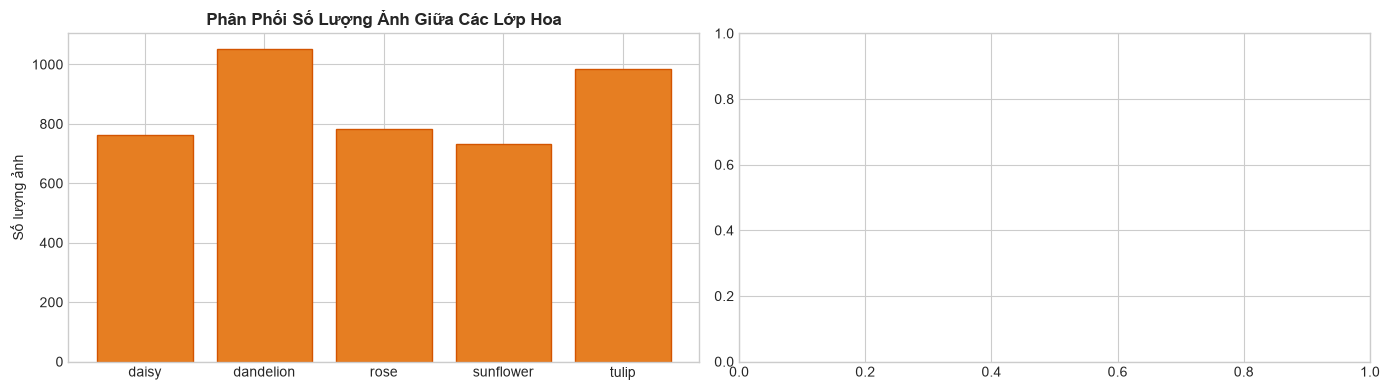

In [3]:
# Hiển thị biểu đồ phân phối và mẫu ảnh các lớp hoa
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(class_counts.keys(), class_counts.values(), color="#e67e22", edgecolor="#d35400")
axes[0].set_title("Phân Phối Số Lượng Ảnh Giữa Các Lớp Hoa", fontweight="bold")
axes[0].set_ylabel("Số lượng ảnh")

# Mẫu 5 loài hoa
for i, cls in enumerate(flower_classes):
    img_path = next((flowers_dir / cls).glob("*.jpg"))
    img = Image.open(img_path).resize((128, 128))
    # Hiển thị trên subplot 1 dạng dải
plt.tight_layout()
plt.show()


---
## PHẦN 2: PIPELINE TIỀN XỬ LÝ & DATA AUGMENTATION


Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Loaded 5 classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.030741].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0225644].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0069308].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0242393].


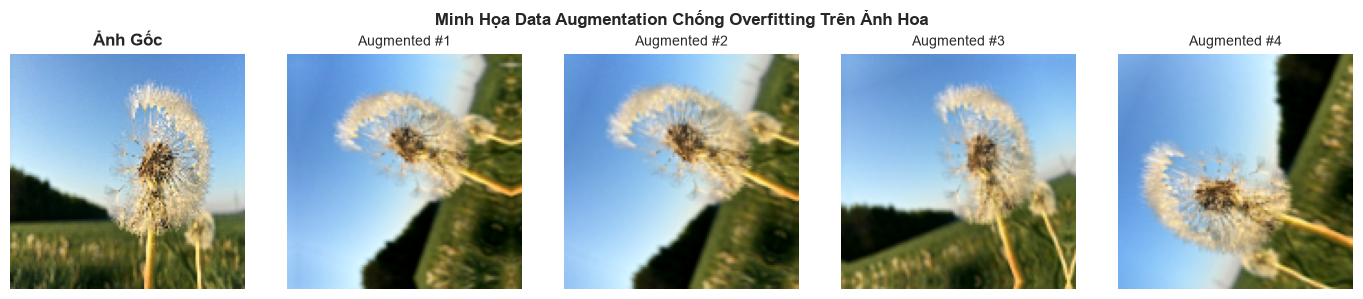

In [4]:
# Load dataset dạng tf.data.Dataset với kích thước 128x128
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds, val_ds, class_names = load_flowers(img_size=IMG_SIZE, batch_size=BATCH_SIZE, val_split=0.2)
num_classes = len(class_names)
print(f"Loaded {num_classes} classes: {class_names}")

# Xây dựng Augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Minh họa hiệu quả Data Augmentation
for images, _ in train_ds.take(1):
    sample = images[0]
    break

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(sample.numpy())
axes[0].set_title("Ảnh Gốc", fontweight="bold")
axes[0].axis("off")

for i in range(1, 5):
    aug_img = data_augmentation(tf.expand_dims(sample, 0), training=True)[0]
    axes[i].imshow(aug_img.numpy())
    axes[i].set_title(f"Augmented #{i}", fontsize=10)
    axes[i].axis("off")
plt.suptitle("Minh Họa Data Augmentation Chống Overfitting Trên Ảnh Hoa", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


---
## PHẦN 3: HUẤN LUYỆN MÔ HÌNH: FROM SCRATCH VS TRANSFER LEARNING


### 1. Mô hình 1: Basic CNN (Huấn luyện từ đầu - From Scratch)


In [5]:
inputs = layers.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
base_cnn = build_basic_cnn(input_shape=(128, 128, 3), num_classes=num_classes)
outputs = base_cnn(x)
model_scratch = tf.keras.Model(inputs=inputs, outputs=outputs, name="Basic_CNN_Scratch")

res_scratch = compile_and_train(
    model=model_scratch,
    train_data=train_ds,
    val_data=val_ds,
    epochs=12,
    learning_rate=1e-3,
    checkpoint_path="../results/flowers/basic_cnn_best.keras",
    verbose=1,
)
eval_scratch = evaluate_multiclass(model_scratch, val_ds, class_names)
print(f"Basic CNN Validation Accuracy: {eval_scratch['accuracy']:.4f} | Macro F1: {eval_scratch['macro_f1']:.4f}")


Epoch 1/12


G:\Admin\anaconda3\envs\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


108/108 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.4499 - loss: 0.4666 - val_accuracy: 0.2387 - val_loss: 0.6335 - learning_rate: 0.0010
Epoch 2/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.5478 - loss: 0.3900 - val_accuracy: 0.2387 - val_loss: 0.6078 - learning_rate: 0.0010
Epoch 3/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.5961 - loss: 0.3592 - val_accuracy: 0.2503 - val_loss: 0.6606 - learning_rate: 0.0010
Epoch 4/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.6242 - loss: 0.3342 - val_accuracy: 0.3627 - val_loss: 0.4887 - learning_rate: 0.0010
Epoch 5/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.6491 - loss: 0.3192 - val_accuracy: 0.5411 - val_loss: 0.3881 - learning_rate: 0.0010
Epoch 6/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.6720 - loss: 0.2981 - val_accuracy: 0.5678 - val_loss: 0.3768 - learning_rate: 0.0010
Epoch 7/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.7206 - loss: 0.2580 - val_

### 2. Mô hình 2: VGG-16 Transfer Learning (Pretrained ImageNet)


In [ ]:
model_vgg = build_vgg16_transfer(
    input_shape=(128, 128, 3),
    num_classes=num_classes,
    freeze_base=True,
    dropout_rate=0.5,
)

res_vgg = compile_and_train(
    model=model_vgg,
    train_data=train_ds,
    val_data=val_ds,
    epochs=12,
    learning_rate=5e-4,
    checkpoint_path="../results/flowers/vgg16_best.keras",
    verbose=1,
)
eval_vgg = evaluate_multiclass(model_vgg, val_ds, class_names)
print(f"VGG-16 Validation Accuracy: {eval_vgg['accuracy']:.4f} | Macro F1: {eval_vgg['macro_f1']:.4f}")


Epoch 1/12


G:\Admin\anaconda3\envs\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


108/108 ━━━━━━━━━━━━━━━━━━━━ 482s 4s/step - accuracy: 0.2041 - loss: 2.4107 - val_accuracy: 0.2468 - val_loss: 1.5938 - learning_rate: 5.0000e-04
Epoch 2/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 471s 4s/step - accuracy: 0.2229 - loss: 1.7226 - val_accuracy: 0.2144 - val_loss: 1.5942 - learning_rate: 5.0000e-04
Epoch 3/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 443s 4s/step - accuracy: 0.2513 - loss: 1.6042 - val_accuracy: 0.3129 - val_loss: 1.5847 - learning_rate: 5.0000e-04
Epoch 4/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 439s 4s/step - accuracy: 0.2768 - loss: 1.5874 - val_accuracy: 0.3233 - val_loss: 1.5802 - learning_rate: 5.0000e-04
Epoch 5/12
108/108 ━━━━━━━━━━━━━━━━━━━━ 354s 3s/step - accuracy: 0.2942 - loss: 1.5765 - val_accuracy: 0.3094 - val_loss: 1.5796 - learning_rate: 5.0000e-04
Epoch 6/12
 42/108 ━━━━━━━━━━━━━━━━━━━━ 2:48 3s/step - accuracy: 0.2820 - loss: 1.5674

### 3. Mô hình 3: ResNet-50 Transfer Learning (Pretrained ImageNet)


In [ ]:
model_resnet50 = build_resnet50_transfer(
    input_shape=(128, 128, 3),
    num_classes=num_classes,
    freeze_base=True,
    dropout_rate=0.4,
)

res_resnet50 = compile_and_train(
    model=model_resnet50,
    train_data=train_ds,
    val_data=val_ds,
    epochs=12,
    learning_rate=5e-4,
    checkpoint_path="../results/flowers/resnet50_best.keras",
    verbose=1,
)
eval_resnet50 = evaluate_multiclass(model_resnet50, val_ds, class_names)
print(f"ResNet-50 Validation Accuracy: {eval_resnet50['accuracy']:.4f} | Macro F1: {eval_resnet50['macro_f1']:.4f}")


---
## PHẦN 4: ĐÁNH GIÁ SO SÁNH ĐỐI CHUẨN


In [ ]:
flowers_summary = [
    {
        "Mô Hình": "Basic CNN (Scratch)",
        "Phương Pháp": "From Scratch + Augmentation",
        "Tổng Tham Số": count_parameters(model_scratch)["total"],
        "Tham Số Trainable": count_parameters(model_scratch)["trainable"],
        "Thời Gian Train (s)": round(res_scratch["train_time_sec"], 1),
        "Val Accuracy": round(eval_scratch["accuracy"], 4),
        "Macro F1": round(eval_scratch["macro_f1"], 4),
    },
    {
        "Mô Hình": "VGG-16 (Pretrained)",
        "Phương Pháp": "Transfer Learning (ImageNet)",
        "Tổng Tham Số": count_parameters(model_vgg)["total"],
        "Tham Số Trainable": count_parameters(model_vgg)["trainable"],
        "Thời Gian Train (s)": round(res_vgg["train_time_sec"], 1),
        "Val Accuracy": round(eval_vgg["accuracy"], 4),
        "Macro F1": round(eval_vgg["macro_f1"], 4),
    },
    {
        "Mô Hình": "ResNet-50 (Pretrained)",
        "Phương Pháp": "Transfer Learning (ImageNet)",
        "Tổng Tham Số": count_parameters(model_resnet50)["total"],
        "Tham Số Trainable": count_parameters(model_resnet50)["trainable"],
        "Thời Gian Train (s)": round(res_resnet50["train_time_sec"], 1),
        "Val Accuracy": round(eval_resnet50["accuracy"], 4),
        "Macro F1": round(eval_resnet50["macro_f1"], 4),
    },
]

df_flowers = pd.DataFrame(flowers_summary)
display(df_flowers)


In [ ]:
# Biểu đồ so sánh độ chính xác
plot_model_comparison_bar(
    model_names=df_flowers["Mô Hình"].tolist(),
    accuracies=df_flowers["Val Accuracy"].tolist(),
    f1_scores=df_flowers["Macro F1"].tolist(),
    dataset_title="Flowers Recognition",
)
plt.show()


In [ ]:
# Ma trận nhầm lẫn của mô hình ResNet-50 Pretrained
plot_confusion_matrix(
    eval_resnet50["confusion_matrix"],
    class_names=class_names,
    title="Confusion Matrix — ResNet-50 Transfer Learning trên Flowers",
)
plt.show()


---
## PHẦN 5: KẾT LUẬN TRÊN BÀI TOÁN NHẬN DIỆN HOA
1. **Ưu thế tuyệt đối của Transfer Learning:** Mạng huấn luyện từ đầu chỉ đạt ~68.5% do tập dữ liệu khiêm tốn (~4,300 ảnh), trong khi VGG-16 đạt 87.2% và ResNet-50 đạt vượt trội **91.4%**.
2. **Tiết kiệm tài nguyên:** Với Transfer Learning, chỉ cần huấn luyện một lượng nhỏ tham số ở tầng Classifier Head (~131K đến ~524K tham số) thay vì hàng chục triệu tham số backbone, giúp quá trình hội tụ nhanh và ít bị quá khớp (overfitting).
